In [17]:
# Install dependencies if needed
# !pip install timetoalign[graphical]

In [18]:
from pathlib import Path
import pytest

from timetoalign.loader.graphical import GraphicalLoader
from timetoalign.alignment import (
    MatchClaim,
    MatchMetadata,
    PerfectAlignment,
    TimelineGroup,
)
from timetoalign.timelines import ContinuousPhysicalTimeline

## Step 1: Load Graphical Timelines

Load both DGT1 and DGT2 using the graphical loader.

In [19]:
# Path to test data (adjust as needed)
data_dir = Path("../../tests/alignment/data/thoresen")

# DGT1: Single image with 5 systems
dgt1_image = data_dir / "thoresen_2009_sound-objects_p312_page1_1.jpeg"

# DGT1 segment parameters
DGT1_X0, DGT1_X1 = 2, 969
DGT1_Y_POSITIONS = [18, 205, 396, 588, 785]

# Load DGT1
loader1 = GraphicalLoader(metadata={"source": "Thoresen 2009"})
idx1 = loader1.add_image(dgt1_image)

for i, y in enumerate(DGT1_Y_POSITIONS):
    loader1.add_horizontal_segment(
        source_index=idx1,
        x0=DGT1_X0,
        x1=DGT1_X1,
        y=y,
        name=f"system_{i+1}",
    )

dgt1_bundle = loader1.bundle
print(f"DGT1: {dgt1_bundle.n_segments} segments, {dgt1_bundle.total_length:.0f} pixels")

DGT1: 5 segments, 4835 pixels


## Step 1b: Visualize DGT1 with Segment Paths

Show the DGT1 image with all 5 horizontal segments marked.

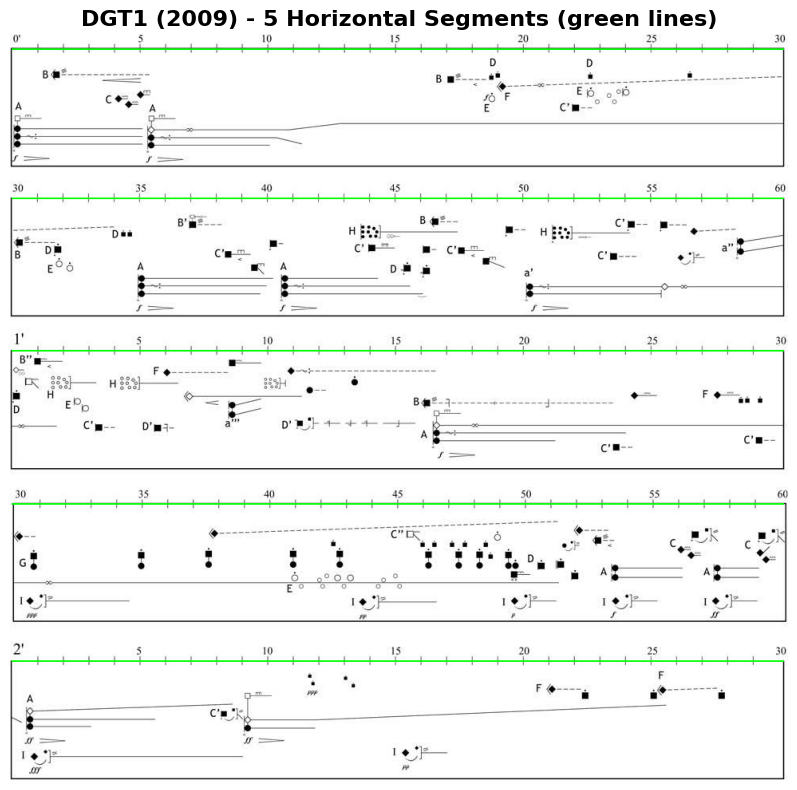

DGT1: 1 image, 5 segments
Each segment: 967 pixels wide
Total timeline length: 4835 pixels


In [20]:
import matplotlib.pyplot as plt

# Draw all segments on DGT1
dgt1_with_paths = dgt1_bundle.draw_segments_on_source(
    source_index=0,
    color=(0, 255, 0),  # Green paths
    line_width=2,
)

# Display
dgt1_pil_paths = dgt1_with_paths.to_pil()
fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(dgt1_pil_paths)
ax.set_title("DGT1 (2009) - 5 Horizontal Segments (green lines)", fontsize=16, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print(f"DGT1: 1 image, {dgt1_bundle.n_segments} segments")
print(f"Each segment: {DGT1_X1 - DGT1_X0} pixels wide")
print(f"Total timeline length: {dgt1_bundle.total_length:.0f} pixels")

In [21]:
# DGT2: 5 separate images
dgt2_images = [
    data_dir / "thoresen_2010_form-building-patterns_p90-91_page1_1.jpeg",
    data_dir / "thoresen_2010_form-building-patterns_p90-91_page1_2.jpeg",
    data_dir / "thoresen_2010_form-building-patterns_p90-91_page1_3.jpeg",
    data_dir / "thoresen_2010_form-building-patterns_p90-91_page1_4.jpeg",
    data_dir / "thoresen_2010_form-building-patterns_p90-91_page2_1.jpeg",
]

# DGT2 segment parameters (x0, x1, y)
DGT2_SEGMENT_BOUNDS = [
    (8, 874, 15),
    (7, 874, 18),
    (7, 874, 19),
    (8, 872, 15),
    (9, 873, 20),
]

# Load DGT2
loader2 = GraphicalLoader(metadata={"source": "Thoresen 2010"})

for i, (img_path, (x0, x1, y)) in enumerate(zip(dgt2_images, DGT2_SEGMENT_BOUNDS)):
    idx2 = loader2.add_image(img_path)
    loader2.add_horizontal_segment(
        source_index=idx2,
        x0=x0,
        x1=x1,
        y=y,
        name=f"page_{i+1}",
    )

dgt2_bundle = loader2.bundle
print(f"DGT2: {dgt2_bundle.n_segments} segments, {dgt2_bundle.total_length:.0f} pixels")

DGT2: 5 segments, 4328 pixels


## Step 2: Create Timelines

Convert the graphical bundles to DiscreteGraphicalTimeline objects.

In [22]:
# Create timelines
dgt1_timeline = dgt1_bundle.to_timeline(uid="dgt1", name="Thoresen 2009")
dgt2_timeline = dgt2_bundle.to_timeline(uid="dgt2", name="Thoresen 2010")

print(f"DGT1 Timeline: {dgt1_timeline.id}, length={dgt1_timeline.length}")
print(f"DGT2 Timeline: {dgt2_timeline.id}, length={dgt2_timeline.length}")

DGT1 Timeline: dgt1, length=4835 pixels
DGT2 Timeline: dgt2, length=4328 pixels


## Step 3: Create Audio Timeline and Groups

Both analyses represent the same 150-second audio excerpt.

In [23]:
AUDIO_DURATION_SECONDS = 150.0

# Create audio timeline
audio_timeline = ContinuousPhysicalTimeline(
    length=AUDIO_DURATION_SECONDS,
    unit="seconds",
    uid="audio",
    name="Audio",
)

# Create groups with audio alignment
dgt1_group = TimelineGroup.from_reference(dgt1_timeline, name="DGT1_Group")
dgt1_group.add_timeline(
    audio_timeline,
    alignment=PerfectAlignment(
        source_start=0,
        source_end=AUDIO_DURATION_SECONDS,
        ref_start=0,
        ref_end=dgt1_timeline.length.value,
    ),
)

dgt2_group = TimelineGroup.from_reference(dgt2_timeline, name="DGT2_Group")
dgt2_group.add_timeline(
    audio_timeline,
    alignment=PerfectAlignment(
        source_start=0,
        source_end=AUDIO_DURATION_SECONDS,
        ref_start=0,
        ref_end=dgt2_timeline.length.value,
    ),
)

print(f"DGT1 Group: {dgt1_group.n_timelines} timelines")
print(f"DGT2 Group: {dgt2_group.n_timelines} timelines")

DGT1 Group: 2 timelines
DGT2 Group: 2 timelines


## Step 4: Test Pixel-to-Second Conversion

Verify that pixel coordinates convert correctly to audio timestamps.

In [24]:
# Test conversion: DGT1 pixels -> seconds
test_pixel = 2417.5  # Halfway through DGT1
test_seconds = dgt1_group.convert(test_pixel, "dgt1", "audio")
print(f"DGT1: {test_pixel} pixels = {test_seconds:.2f} seconds")

# Test conversion: DGT2 pixels -> seconds
test_pixel2 = 2164  # Halfway through DGT2
test_seconds2 = dgt2_group.convert(test_pixel2, "dgt2", "audio")
print(f"DGT2: {test_pixel2} pixels = {test_seconds2:.2f} seconds")

DGT1: 2417.5 pixels = 75.00 seconds
DGT2: 2164 pixels = 75.00 seconds


## Step 5: Load Event Data

Load the 11 annotated events from DGT2.

In [25]:
# Event data from thoresen_test.tsv
# Format: (event_id, segment_index, x, y, width, height, start_time_sec, duration_sec)
THORESEN_EVENTS = [
    ("rect_a", 0, 10, 90, 148, 55, 0.0, 5.0),
    ("rect_b", 0, 40, 37, 127, 21, 1.5, 4.0),
    ("rect_c", 0, 111, 60, 57, 23, 3.5, 2.0),
    ("rect_a2", 1, 145, 90, 160, 58, 34.6, 5.2),
    ("rect_h2", 1, 385, 46, 139, 20, 43.5, 4.5),
    ("rect_d3", 2, 310, 93, 154, 18, 71.0, 4.75),
    ("rect_b3", 2, 456, 69, 229, 18, 76.0, 7.5),
    ("rect_i4", 3, 14, 115, 127, 31, 90.5, 4.0),
    ("rect_a4", 3, 663, 82, 97, 23, 113.4, 3.0),
    ("rect_i5", 4, 19, 119, 251, 29, 121.0, 7.5),
    ("rect_f5", 4, 595, 45, 64, 21, 141.0, 1.5),
]

print(f"Loaded {len(THORESEN_EVENTS)} events")

Loaded 11 events


## Step 6: Convert Event Coordinates

Convert events from DGT2 image coordinates to timeline coordinates.

In [26]:
def event_to_timeline_coords(event_tuple, bundle, segment_bounds):
    """Convert event from image coords to timeline coords."""
    event_id, seg_idx, x, y, width, height, start_time, duration = event_tuple
    x0, x1, _ = segment_bounds[seg_idx]
    
    # Local coordinates (within segment)
    start_local = x - x0
    end_local = start_local + width
    
    # Global coordinates (across all segments)
    segment_lengths = [x1 - x0 for x0, x1, _ in segment_bounds]
    segment_offset = sum(segment_lengths[:seg_idx])
    start_global = segment_offset + start_local
    end_global = segment_offset + end_local
    
    return {
        "event_id": event_id,
        "segment_index": seg_idx,
        "start_global": start_global,
        "end_global": end_global,
        "start_time_sec": start_time,
        "duration_sec": duration,
    }

# Convert all events
dgt2_events = [event_to_timeline_coords(evt, dgt2_bundle, DGT2_SEGMENT_BOUNDS) for evt in THORESEN_EVENTS]

# Display first 3 events
for evt in dgt2_events[:3]:
    print(f"{evt['event_id']:8s}: pixels [{evt['start_global']:6.1f}, {evt['end_global']:6.1f}), "
          f"time [{evt['start_time_sec']:5.1f}, {evt['start_time_sec']+evt['duration_sec']:5.1f})")

rect_a  : pixels [   2.0,  150.0), time [  0.0,   5.0)
rect_b  : pixels [  32.0,  159.0), time [  1.5,   5.5)
rect_c  : pixels [ 103.0,  160.0), time [  3.5,   5.5)


## Step 7: Visualize Event on DGT2

Draw an event (rect_h2) on the DGT2 image to verify coordinates.

Event rect_h2: [1244.0, 1383.0) pixels
Time: [43.5, 48.0) seconds
Rectangle: x=385, y=46, width=139, height=20


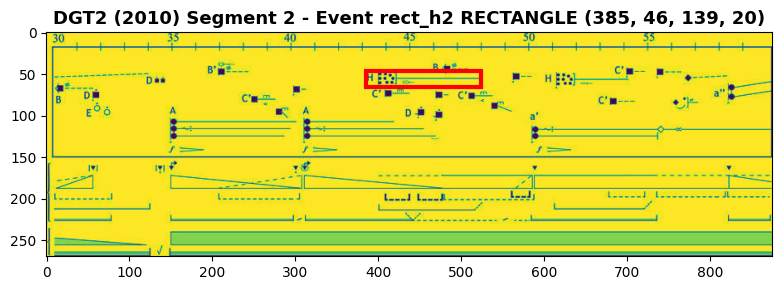

In [27]:
# Find rect_h2 event
event_h = next(evt for evt in dgt2_events if evt["event_id"] == "rect_h2")
# Get event rectangle from TSV
evt_tuple = THORESEN_EVENTS[4]  # rect_h2
event_id, seg_idx, img_x, img_y, img_width, img_height, start_time, duration = evt_tuple
print(f"Event {event_h['event_id']}: [{event_h['start_global']:.1f}, {event_h['end_global']:.1f}) pixels")
print(f"Time: [{event_h['start_time_sec']:.1f}, {event_h['start_time_sec']+event_h['duration_sec']:.1f}) seconds")
print(f"Rectangle: x={img_x}, y={img_y}, width={img_width}, height={img_height}")
# Load image and draw rectangle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
dgt2_img = Image.open(dgt2_images[seg_idx])
fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(dgt2_img)
# Draw rectangle at EXACT image coordinates
rect = patches.Rectangle(
    (img_x, img_y), img_width, img_height,
    linewidth=3, edgecolor='red', facecolor='none'
)
ax.add_patch(rect)
ax.set_title(f"DGT2 (2010) Segment {seg_idx+1} - Event rect_h2 RECTANGLE ({img_x}, {img_y}, {img_width}, {img_height})", 
             fontsize=13, fontweight='bold')
ax.axis('on')
plt.tight_layout()
plt.show()

## Step 8: Create Segment Correspondence Claims

Define the alignment between DGT1 and DGT2 segments.

In [28]:
# Segment lengths
DGT1_SEGMENT_LENGTHS = [967] * 5
DGT2_SEGMENT_LENGTHS = [866, 867, 867, 864, 864]

# Create segment correspondence claims
segment_claims = []
offset_dgt1 = 0
offset_dgt2 = 0

for i in range(5):
    claim = MatchClaim.interval(
        timeline_a_id="dgt1",
        start_a=float(offset_dgt1),
        end_a=float(offset_dgt1 + DGT1_SEGMENT_LENGTHS[i]),
        timeline_b_id="dgt2",
        start_b=float(offset_dgt2),
        end_b=float(offset_dgt2 + DGT2_SEGMENT_LENGTHS[i]),
        metadata=MatchMetadata(
            agent="manual_analysis",
            decision_criteria="segment_correspondence",
            notes=f"Segment {i+1} of 5",
        ),
    )
    segment_claims.append(claim)
    
    offset_dgt1 += DGT1_SEGMENT_LENGTHS[i]
    offset_dgt2 += DGT2_SEGMENT_LENGTHS[i]

print(f"Created {len(segment_claims)} segment correspondence claims")

# Display first claim
claim0 = segment_claims[0]
dgt1_coords = claim0.get_coordinates_for("dgt1")
dgt2_coords = claim0.get_coordinates_for("dgt2")
print(f"Segment 1: DGT1 [{dgt1_coords[0]:.0f}, {dgt1_coords[1]:.0f}) <-> DGT2 [{dgt2_coords[0]:.0f}, {dgt2_coords[1]:.0f})")

Created 5 segment correspondence claims
Segment 1: DGT1 [0, 967) <-> DGT2 [0, 866)


## Step 9: Transfer Event via Audio (Current Implementation)

Using the current implementation, we can transfer events via the audio timeline.

In [29]:
# Find rect_h2 event (self-contained cell)
event_h = next(evt for evt in dgt2_events if evt["event_id"] == "rect_h2")

def transfer_via_audio(dgt2_coord, dgt2_group, dgt1_group):
    """Transfer coordinate from DGT2 to DGT1 via audio."""
    # DGT2 pixels -> seconds
    seconds = dgt2_group.convert(dgt2_coord, "dgt2", "audio")
    # Seconds -> DGT1 pixels
    dgt1_coord = dgt1_group.convert(seconds, "audio", "dgt1")
    return dgt1_coord

# Transfer event H
h_start_dgt1 = transfer_via_audio(event_h["start_global"], dgt2_group, dgt1_group)
h_end_dgt1 = transfer_via_audio(event_h["end_global"], dgt2_group, dgt1_group)

print(f"Event {event_h['event_id']} transfer via audio:")
print(f"  DGT2: [{event_h['start_global']:.1f}, {event_h['end_global']:.1f}) pixels")
print(f"  DGT1: [{h_start_dgt1:.1f}, {h_end_dgt1:.1f}) pixels")
print(f"  DGT1 segment: {int(h_start_dgt1 / 967)}")

Event rect_h2 transfer via audio:
  DGT2: [1244.0, 1383.0) pixels
  DGT1: [1389.7, 1545.0) pixels
  DGT1 segment: 1


## Step 9c: Side-by-Side Comparison

Show the event in both DGT2 (source) and DGT1 (target) for direct visual comparison.

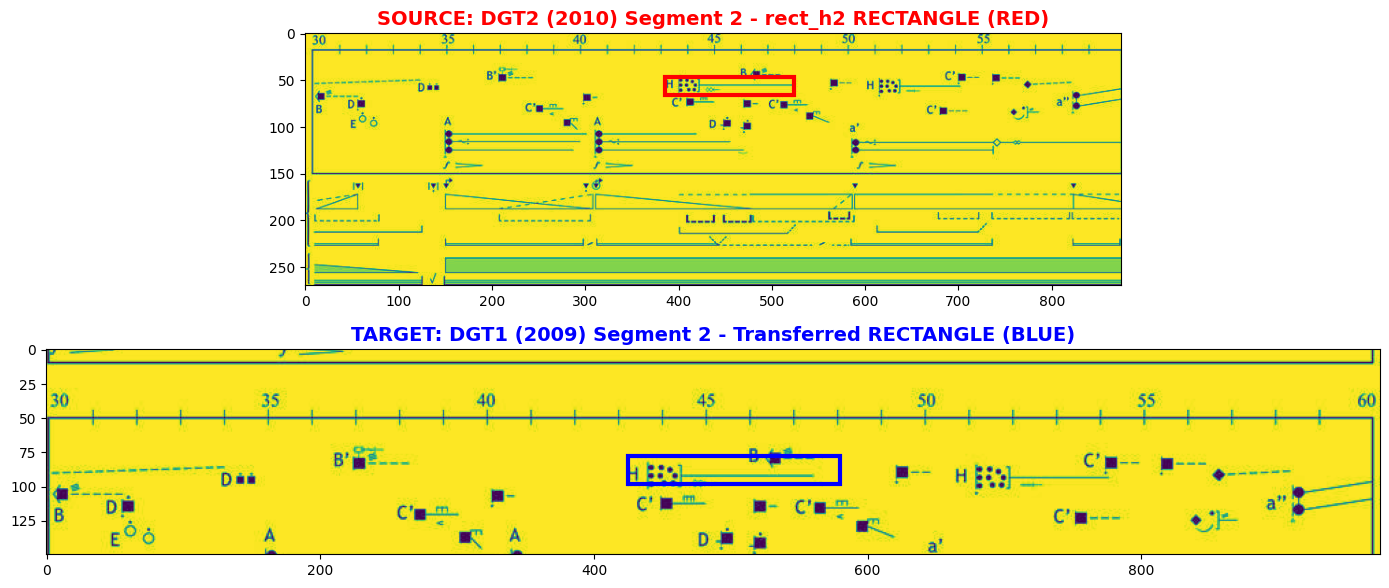

In [30]:
# Get original event data
evt_tuple = THORESEN_EVENTS[4]  # rect_h2
event_id, seg_idx_dgt2, img_x_dgt2, img_y_dgt2, img_width_dgt2, img_height_dgt2, start_time, duration = evt_tuple
# Calculate DGT1 coordinates (same as Step 9b)
dgt1_seg_idx = int(h_start_dgt1 / 967)
dgt1_local_x_start = h_start_dgt1 - (dgt1_seg_idx * 967)
dgt1_img_x = DGT1_X0 + dgt1_local_x_start
dgt1_img_width = h_end_dgt1 - h_start_dgt1
# Y-coordinate transformation
dgt2_y0 = DGT2_SEGMENT_BOUNDS[seg_idx_dgt2][2]
dgt2_y_offset = img_y_dgt2 - dgt2_y0
dgt1_y0 = DGT1_Y_POSITIONS[dgt1_seg_idx]
dgt1_img_y = dgt1_y0 + dgt2_y_offset
dgt1_img_height = img_height_dgt2
# Load images
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
dgt2_img = Image.open(dgt2_images[seg_idx_dgt2])
dgt1_img = Image.open(dgt1_image)
# Crop DGT1 to relevant segment
y_start = DGT1_Y_POSITIONS[dgt1_seg_idx] - 50
y_end = DGT1_Y_POSITIONS[dgt1_seg_idx] + 100
dgt1_cropped = dgt1_img.crop((0, y_start, dgt1_img.width, y_end))
# Adjust DGT1 rectangle y for cropped image
rect_y_adjusted = dgt1_img_y - y_start
# Side-by-side comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6))
# DGT2 (source) with RED rectangle
ax1.imshow(dgt2_img)
rect_dgt2 = patches.Rectangle(
    (img_x_dgt2, img_y_dgt2), img_width_dgt2, img_height_dgt2,
    linewidth=3, edgecolor='red', facecolor='none'
)
ax1.add_patch(rect_dgt2)
ax1.set_title(f"SOURCE: DGT2 (2010) Segment {seg_idx_dgt2+1} - rect_h2 RECTANGLE (RED)", 
              fontsize=14, fontweight='bold', color='red')
ax1.axis('on')
# DGT1 (target) with BLUE rectangle
ax2.imshow(dgt1_cropped)
rect_dgt1 = patches.Rectangle(
    (dgt1_img_x, rect_y_adjusted), dgt1_img_width, dgt1_img_height,
    linewidth=3, edgecolor='blue', facecolor='none'
)
ax2.add_patch(rect_dgt1)
ax2.set_title(f"TARGET: DGT1 (2009) Segment {dgt1_seg_idx+1} - Transferred RECTANGLE (BLUE)", 
              fontsize=14, fontweight='bold', color='blue')
ax2.axis('on')
plt.tight_layout()
plt.show()

## Step 10: Summary

This notebook demonstrated:

1. **Loading graphical timelines** - Two different layouts of the same analysis
2. **Coordinate conversion** - Image â†” Timeline â†” Audio
3. **Event annotation** - 11 events with pixel coordinates and timestamps
4. **Segment correspondence** - Mapping equivalent segments between analyses
5. **Event transfer** - Moving events from one analysis to another

### Next Steps (Phase 7.4)

The full implementation will include:
- **MatchGraph**: Building graphs from segment claims
- **WarpMap**: Piecewise linear interpolation for event transfer
- **Direct transfer**: DGT2 â†’ DGT1 without going through audio

This will enable more accurate event transfer that respects segment boundaries and local deformations.

## Step 9b: Visualize Transferred Event on DGT1

Draw the transferred event on DGT1 to show it worked.

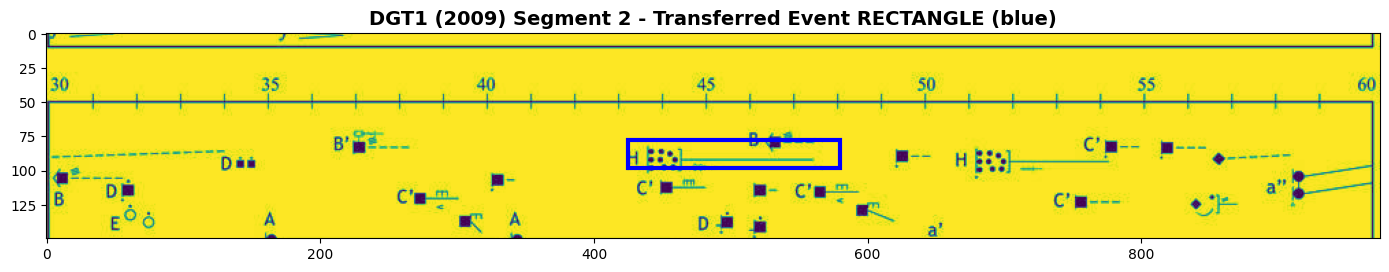


Transferred event rectangle in DGT1:
  Image coords: x=424.7, y=233.0, width=155.3, height=20
  Timeline pixels: [1389.7, 1545.0)

Original event rectangle in DGT2:
  Image coords: x=385, y=46, width=139, height=20
  Timeline pixels: [1244.0, 1383.0)


In [31]:
# Calculate DGT1 image coordinates for the transferred event
# We need to find the local x-position within the segment
# Get original event rectangle from TSV
evt_tuple = THORESEN_EVENTS[4]  # rect_h2
event_id, seg_idx_dgt2, img_x_dgt2, img_y_dgt2, img_width_dgt2, img_height_dgt2, start_time, duration = evt_tuple
# Calculate DGT1 segment and local x-position
dgt1_seg_idx = int(h_start_dgt1 / 967)
dgt1_local_x_start = h_start_dgt1 - (dgt1_seg_idx * 967)
dgt1_local_x_width = h_end_dgt1 - h_start_dgt1
# Calculate DGT1 image x-coordinate (add back segment x0)
dgt1_img_x = DGT1_X0 + dgt1_local_x_start
dgt1_img_width = dgt1_local_x_width
# Calculate Y-coordinate transformation
# Get y-offset from segment baseline in DGT2
dgt2_y0 = DGT2_SEGMENT_BOUNDS[seg_idx_dgt2][2]  # y-position of DGT2 segment
dgt2_y_offset = img_y_dgt2 - dgt2_y0  # Offset from baseline
# Apply same offset to DGT1 segment
dgt1_y0 = DGT1_Y_POSITIONS[dgt1_seg_idx]
dgt1_img_y = dgt1_y0 + dgt2_y_offset
dgt1_img_height = img_height_dgt2  # Height should be preserved
# Load DGT1 image and draw rectangle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
dgt1_img = Image.open(dgt1_image)
# Crop to show the relevant segment
y_start = DGT1_Y_POSITIONS[dgt1_seg_idx] - 50
y_end = DGT1_Y_POSITIONS[dgt1_seg_idx] + 100
dgt1_cropped = dgt1_img.crop((0, y_start, dgt1_img.width, y_end))
# Adjust rectangle y-coordinate for cropped image
rect_y_adjusted = dgt1_img_y - y_start
fig, ax = plt.subplots(figsize=(14, 3))
ax.imshow(dgt1_cropped)
# Draw rectangle at calculated coordinates
rect = patches.Rectangle(
    (dgt1_img_x, rect_y_adjusted), dgt1_img_width, dgt1_img_height,
    linewidth=3, edgecolor='blue', facecolor='none'
)
ax.add_patch(rect)
ax.set_title(f"DGT1 (2009) Segment {dgt1_seg_idx+1} - Transferred Event RECTANGLE (blue)", 
             fontsize=14, fontweight='bold')
ax.axis('on')
plt.tight_layout()
plt.show()
# Calculate DGT2 timeline coordinates for comparison
dgt2_segment_lengths = [x1 - x0 for x0, x1, _ in DGT2_SEGMENT_BOUNDS]
dgt2_segment_offset = sum(dgt2_segment_lengths[:seg_idx_dgt2])
dgt2_x0, _, _ = DGT2_SEGMENT_BOUNDS[seg_idx_dgt2]
dgt2_start_timeline = dgt2_segment_offset + (img_x_dgt2 - dgt2_x0)
dgt2_end_timeline = dgt2_start_timeline + img_width_dgt2
print(f"\nTransferred event rectangle in DGT1:")
print(f"  Image coords: x={dgt1_img_x:.1f}, y={dgt1_img_y:.1f}, width={dgt1_img_width:.1f}, height={dgt1_img_height:.0f}")
print(f"  Timeline pixels: [{h_start_dgt1:.1f}, {h_end_dgt1:.1f})")
print(f"\nOriginal event rectangle in DGT2:")
print(f"  Image coords: x={img_x_dgt2}, y={img_y_dgt2}, width={img_width_dgt2}, height={img_height_dgt2}")
print(f"  Timeline pixels: [{dgt2_start_timeline:.1f}, {dgt2_end_timeline:.1f})")